# Financial Market Pricing Analysis

## Project Goal
This project analyzes financial market pricing data to identify unusual price movements, missing prices, stale prices, and pricing exceptions. The purpose is to simulate the type of daily pricing review used in investment operations, fund servicing, financial operations, and FinTech environments.

The analysis focuses on:
- Daily price movement review
- Pricing exception identification
- Data quality checks
- Vendor-level pricing review
- Asset class comparison
- Business-ready insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

## 1. Create a Synthetic Market Pricing Dataset

Since this is a portfolio project, I created a realistic synthetic dataset that represents daily security pricing data from different pricing vendors. The dataset includes equities, ETFs, crypto, and fixed income ETF pricing records.

The dataset contains:
- Security identifiers
- Tickers and security names
- Asset classes
- Pricing vendors
- Previous close prices
- Current prices
- Daily percentage changes
- Pricing status
- Exception flags
- Exception reasons

In [3]:
from datetime import datetime, timedelta
import random

random.seed(42)
np.random.seed(42)

securities = [
    {"security_id": "SEC001", "ticker": "AAPL", "security_name": "Apple Inc.", "asset_class": "Equity", "base_price": 185.00},
    {"security_id": "SEC002", "ticker": "MSFT", "security_name": "Microsoft Corp.", "asset_class": "Equity", "base_price": 410.00},
    {"security_id": "SEC003", "ticker": "JPM", "security_name": "JPMorgan Chase & Co.", "asset_class": "Equity", "base_price": 195.00},
    {"security_id": "SEC004", "ticker": "TSLA", "security_name": "Tesla Inc.", "asset_class": "Equity", "base_price": 240.00},
    {"security_id": "SEC005", "ticker": "SPY", "security_name": "SPDR S&P 500 ETF", "asset_class": "ETF", "base_price": 515.00},
    {"security_id": "SEC006", "ticker": "QQQ", "security_name": "Invesco QQQ Trust", "asset_class": "ETF", "base_price": 440.00},
    {"security_id": "SEC007", "ticker": "BTC-USD", "security_name": "Bitcoin USD", "asset_class": "Crypto", "base_price": 65000.00},
    {"security_id": "SEC008", "ticker": "BND", "security_name": "Vanguard Total Bond Market ETF", "asset_class": "Fixed Income ETF", "base_price": 72.00},
]

vendors = ["Bloomberg", "Reuters", "ICE Data Services", "Internal Feed"]

start_date = datetime(2025, 7, 1)
business_days = []
current_date = start_date

while len(business_days) < 60:
    if current_date.weekday() < 5:
        business_days.append(current_date)
    current_date += timedelta(days=1)

rows = []

for security in securities:
    previous_close = security["base_price"]

    for date in business_days:
        vendor = random.choice(vendors)

        if security["asset_class"] == "Crypto":
            daily_change = random.uniform(-4.5, 4.5)
        elif security["asset_class"] == "Equity":
            daily_change = random.uniform(-2.8, 2.8)
        else:
            daily_change = random.uniform(-1.2, 1.2)

        current_price = previous_close * (1 + daily_change / 100)

        exception_flag = "No"
        exception_reason = "Normal price movement"
        pricing_status = "Reviewed"

        random_event = random.random()

        if random_event < 0.015:
            current_price = np.nan
            daily_change_value = np.nan
            exception_flag = "Yes"
            exception_reason = "Missing vendor price"
            pricing_status = "Needs Review"

        elif random_event < 0.035:
            daily_change = random.choice([7.8, -8.4, 10.2, -9.6])
            current_price = previous_close * (1 + daily_change / 100)
            daily_change_value = daily_change
            exception_flag = "Yes"
            exception_reason = "Large market movement"
            pricing_status = "Needs Review"

        elif random_event < 0.05:
            current_price = previous_close
            daily_change_value = 0.00
            exception_flag = "Yes"
            exception_reason = "Possible stale price"
            pricing_status = "Needs Review"

        else:
            daily_change_value = daily_change

        rows.append({
            "pricing_date": date.strftime("%Y-%m-%d"),
            "security_id": security["security_id"],
            "ticker": security["ticker"],
            "security_name": security["security_name"],
            "asset_class": security["asset_class"],
            "currency": "USD",
            "pricing_vendor": vendor,
            "previous_close": round(previous_close, 2),
            "current_price": round(current_price, 2) if not pd.isna(current_price) else np.nan,
            "daily_change_pct": round(daily_change_value, 2) if not pd.isna(daily_change_value) else np.nan,
            "volume": random.randint(50000, 5000000) if not pd.isna(current_price) else np.nan,
            "pricing_status": pricing_status,
            "exception_flag": exception_flag,
            "exception_reason": exception_reason,
        })

        if not pd.isna(current_price):
            previous_close = current_price

df = pd.DataFrame(rows)

data_path = Path("../data/market_pricing_data.csv")
data_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(data_path, index=False)

df.head()

,pricing_date,security_id,ticker,security_name,asset_class,currency,pricing_vendor,previous_close,current_price,daily_change_pct,volume,pricing_status,exception_flag,exception_reason
0,2025-07-01,SEC001,AAPL,Apple Inc.,Equity,USD,Bloomberg,185.00,180.08,-2.66,1922427.0,Reviewed,No,Normal price movement
1,2025-07-02,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,180.08,182.46,1.32,4624866.0,Reviewed,No,Normal price movement
2,2025-07-03,SEC001,AAPL,Apple Inc.,Equity,USD,Bloomberg,182.46,196.70,7.80,1884068.0,Needs Review,Yes,Large market movement
3,2025-07-04,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,196.70,180.17,-8.40,4621300.0,Needs Review,Yes,Large market movement
4,2025-07-07,SEC001,AAPL,Apple Inc.,Equity,USD,Internal Feed,180.17,177.35,-1.57,104515.0,Reviewed,No,Normal price movement


## 2. Initial Data Review

The next step is to inspect the dataset and understand its structure, size, columns, and possible data quality issues.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 480
Columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pricing_date      480 non-null    str    
 1   security_id       480 non-null    str    
 2   ticker            480 non-null    str    
 3   security_name     480 non-null    str    
 4   asset_class       480 non-null    str    
 5   currency          480 non-null    str    
 6   pricing_vendor    480 non-null    str    
 7   previous_close    480 non-null    float64
 8   current_price     477 non-null    float64
 9   daily_change_pct  477 non-null    float64
 10  volume            477 non-null    float64
 11  pricing_status    480 non-null    str    
 12  exception_flag    480 non-null    str    
 13  exception_reason  480 non-null    str    
dtypes: float64(4), str(10)
memory usage: 52.6 KB


In [5]:
df.describe()

,previous_close,current_price,daily_change_pct,volume
count,480.000000,477.000000,477.000000,4.770000e+02
mean,8030.494146,8080.125660,0.239057,2.574368e+06
std,20437.739014,20493.975206,2.105432,1.430378e+06
min,70.620000,70.620000,-8.400000,6.418700e+04
25%,188.400000,188.420000,-0.920000,1.299404e+06
50%,366.145000,402.780000,0.040000,2.587697e+06
75%,512.592500,511.790000,1.100000,3.780379e+06
max,67258.180000,67258.180000,10.200000,4.997513e+06


## 3. Data Quality Checks

Pricing data needs to be reviewed carefully because missing prices, stale prices, and large price movements can create operational risk. In this section, I check for missing values and pricing records that need review.

In [6]:
missing_values = df.isna().sum()
missing_values

pricing_date        0
security_id         0
ticker              0
security_name       0
asset_class         0
currency            0
pricing_vendor      0
previous_close      0
current_price       3
daily_change_pct    3
volume              3
pricing_status      0
exception_flag      0
exception_reason    0
dtype: int64

In [7]:
exceptions = df[df["exception_flag"] == "Yes"]

exceptions.head(10)

,pricing_date,security_id,ticker,security_name,asset_class,currency,pricing_vendor,previous_close,current_price,daily_change_pct,volume,pricing_status,exception_flag,exception_reason
2,2025-07-03,SEC001,AAPL,Apple Inc.,Equity,USD,Bloomberg,182.46,196.70,7.8,1884068.0,Needs Review,Yes,Large market movement
3,2025-07-04,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,196.70,180.17,-8.4,4621300.0,Needs Review,Yes,Large market movement
10,2025-07-15,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,182.60,182.60,0.0,1961749.0,Needs Review,Yes,Possible stale price
23,2025-08-01,SEC001,AAPL,Apple Inc.,Equity,USD,Internal Feed,180.97,180.97,0.0,969803.0,Needs Review,Yes,Possible stale price
41,2025-08-27,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,188.54,172.70,-8.4,4986193.0,Needs Review,Yes,Large market movement
43,2025-08-29,SEC001,AAPL,Apple Inc.,Equity,USD,Reuters,167.94,185.07,10.2,644394.0,Needs Review,Yes,Large market movement
56,2025-09-17,SEC001,AAPL,Apple Inc.,Equity,USD,Bloomberg,175.27,NaN,NaN,NaN,Needs Review,Yes,Missing vendor price
87,2025-08-07,SEC002,MSFT,Microsoft Corp.,Equity,USD,Reuters,418.85,461.57,10.2,3503700.0,Needs Review,Yes,Large market movement
157,2025-08-21,SEC003,JPM,JPMorgan Chase & Co.,Equity,USD,Internal Feed,203.31,224.04,10.2,1908885.0,Needs Review,Yes,Large market movement
202,2025-07-31,SEC004,TSLA,Tesla Inc.,Equity,USD,Reuters,254.60,NaN,NaN,NaN,Needs Review,Yes,Missing vendor price


In [8]:
exception_summary = (
    df.groupby("exception_reason")
    .size()
    .reset_index(name="record_count")
    .sort_values(by="record_count", ascending=False)
)

exception_summary

,exception_reason,record_count
2,Normal price movement,459
0,Large market movement,13
3,Possible stale price,5
1,Missing vendor price,3


## 4. Pricing Exception Analysis

This section reviews how many pricing records were normal and how many needed review. This is useful for operations teams because it helps prioritize which securities or vendors need attention.

In [9]:
status_summary = (
    df.groupby("pricing_status")
    .size()
    .reset_index(name="record_count")
)

status_summary

,pricing_status,record_count
0,Needs Review,21
1,Reviewed,459


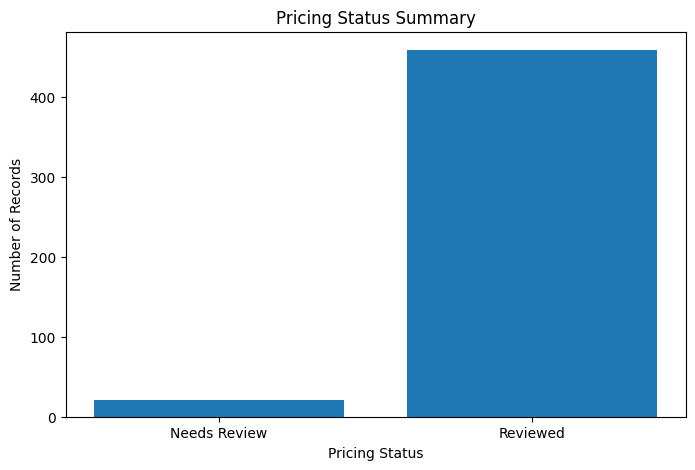

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(status_summary["pricing_status"], status_summary["record_count"])
plt.title("Pricing Status Summary")
plt.xlabel("Pricing Status")
plt.ylabel("Number of Records")
plt.show()

## 5. Asset Class Analysis

Different asset classes behave differently. For example, crypto prices are usually more volatile than ETFs or fixed income products. This section compares daily price movement across asset classes.

In [11]:
asset_class_summary = (
    df.groupby("asset_class")
    .agg(
        average_daily_change_pct=("daily_change_pct", "mean"),
        max_daily_change_pct=("daily_change_pct", "max"),
        min_daily_change_pct=("daily_change_pct", "min"),
        exception_count=("exception_flag", lambda x: (x == "Yes").sum())
    )
    .reset_index()
    .sort_values(by="exception_count", ascending=False)
)

asset_class_summary

,asset_class,average_daily_change_pct,max_daily_change_pct,min_daily_change_pct,exception_count
2,Equity,0.293151,10.2,-8.40,10
0,Crypto,0.052167,7.8,-8.40,5
1,ETF,0.252605,10.2,-1.16,4
3,Fixed Income ETF,0.184500,10.2,-1.18,2


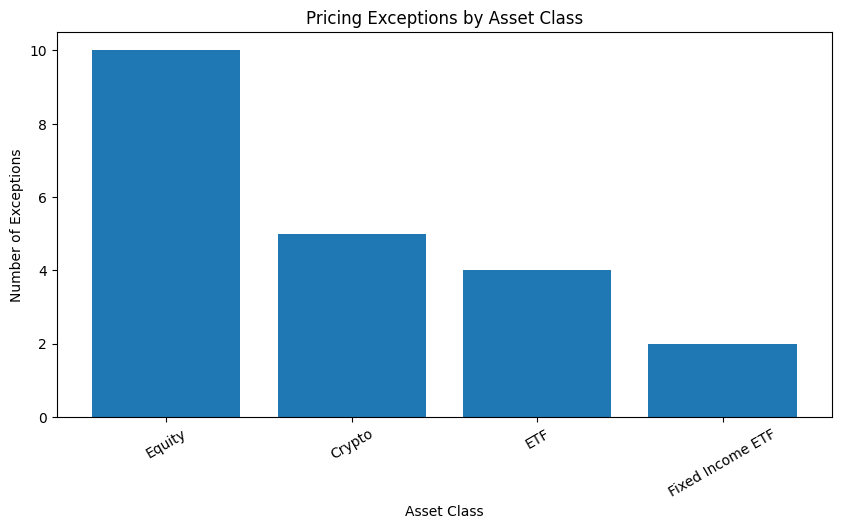

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(asset_class_summary["asset_class"], asset_class_summary["exception_count"])
plt.title("Pricing Exceptions by Asset Class")
plt.xlabel("Asset Class")
plt.ylabel("Number of Exceptions")
plt.xticks(rotation=30)
plt.show()

## 6. Vendor-Level Review

Pricing vendors are important because financial institutions often receive pricing data from different external and internal sources. This section reviews which vendors had the highest number of pricing exceptions.

In [13]:
vendor_summary = (
    df.groupby("pricing_vendor")
    .agg(
        total_records=("pricing_vendor", "count"),
        exception_count=("exception_flag", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

vendor_summary["exception_rate_pct"] = round(
    vendor_summary["exception_count"] / vendor_summary["total_records"] * 100, 2
)

vendor_summary.sort_values(by="exception_rate_pct", ascending=False)

,pricing_vendor,total_records,exception_count,exception_rate_pct
3,Reuters,117,7,5.98
0,Bloomberg,108,6,5.56
1,ICE Data Services,118,4,3.39
2,Internal Feed,137,4,2.92


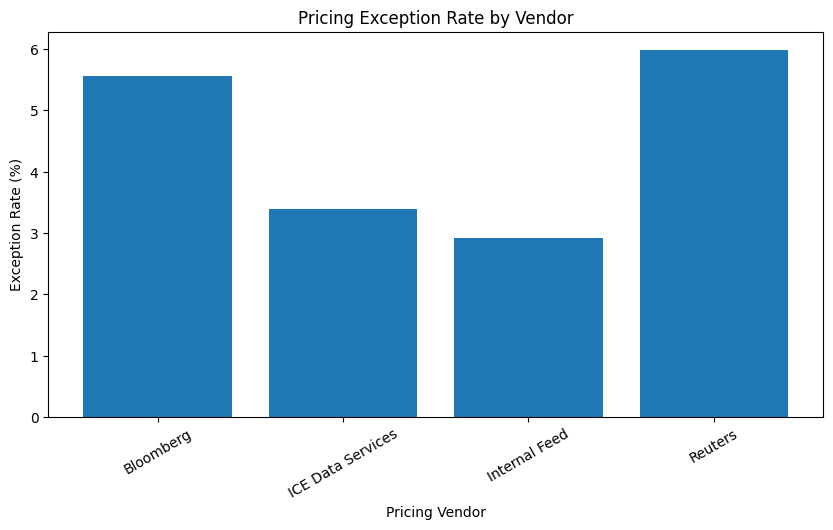

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(vendor_summary["pricing_vendor"], vendor_summary["exception_rate_pct"])
plt.title("Pricing Exception Rate by Vendor")
plt.xlabel("Pricing Vendor")
plt.ylabel("Exception Rate (%)")
plt.xticks(rotation=30)
plt.show()

## 7. Largest Daily Price Movements

Large price movements should be reviewed because they may represent real market changes or possible pricing errors.

In [15]:
largest_movements = (
    df.dropna(subset=["daily_change_pct"])
    .assign(abs_change=lambda x: x["daily_change_pct"].abs())
    .sort_values(by="abs_change", ascending=False)
    .head(10)
)

largest_movements[
    ["pricing_date", "ticker", "security_name", "asset_class", "pricing_vendor", "previous_close", "current_price", "daily_change_pct", "exception_reason"]
]

,pricing_date,ticker,security_name,asset_class,pricing_vendor,previous_close,current_price,daily_change_pct,exception_reason
441,2025-07-30,BND,Vanguard Total Bond Market ETF,Fixed Income ETF,ICE Data Services,74.52,82.12,10.2,Large market movement
241,2025-07-02,SPY,SPDR S&P 500 ETF,ETF,ICE Data Services,516.59,569.28,10.2,Large market movement
87,2025-08-07,MSFT,Microsoft Corp.,Equity,Reuters,418.85,461.57,10.2,Large market movement
157,2025-08-21,JPM,JPMorgan Chase & Co.,Equity,Internal Feed,203.31,224.04,10.2,Large market movement
308,2025-07-11,QQQ,Invesco QQQ Trust,ETF,ICE Data Services,416.51,458.99,10.2,Large market movement
43,2025-08-29,AAPL,Apple Inc.,Equity,Reuters,167.94,185.07,10.2,Large market movement
41,2025-08-27,AAPL,Apple Inc.,Equity,Reuters,188.54,172.70,-8.4,Large market movement
391,2025-08-13,BTC-USD,Bitcoin USD,Crypto,Reuters,63829.38,58467.71,-8.4,Large market movement
3,2025-07-04,AAPL,Apple Inc.,Equity,Reuters,196.70,180.17,-8.4,Large market movement
355,2025-09-16,QQQ,Invesco QQQ Trust,ETF,Bloomberg,474.76,511.79,7.8,Large market movement


## 8. Key Business Insights

Based on the analysis, the main findings are summarized below.

In [16]:
total_records = len(df)
total_exceptions = (df["exception_flag"] == "Yes").sum()
exception_rate = round(total_exceptions / total_records * 100, 2)

top_exception_reason = exception_summary.iloc[0]["exception_reason"]
highest_exception_vendor = vendor_summary.sort_values(by="exception_rate_pct", ascending=False).iloc[0]["pricing_vendor"]
highest_exception_asset_class = asset_class_summary.iloc[0]["asset_class"]

print(f"Total pricing records reviewed: {total_records}")
print(f"Total pricing exceptions: {total_exceptions}")
print(f"Overall exception rate: {exception_rate}%")
print(f"Most common exception reason: {top_exception_reason}")
print(f"Vendor with highest exception rate: {highest_exception_vendor}")
print(f"Asset class with highest exception count: {highest_exception_asset_class}")

Total pricing records reviewed: 480
Total pricing exceptions: 21
Overall exception rate: 4.38%
Most common exception reason: Normal price movement
Vendor with highest exception rate: Reuters
Asset class with highest exception count: Equity
